# Setup

In [ ]:
# import libraries used in this notebook
from scipy.io import loadmat
import pandas as pd
import numpy as np
import glob
import os
import re
import google.colab.drive as drive
from scipy.stats import norm
import math
import scipy.integrate as integrate
from typing import List
import matplotlib.pyplot as plt

In [ ]:
# mount your google drive to this colab runtime
mountpoint = '/content/G' # arbitrary mountpoint
drive.mount(mountpoint)
# when prompted, connect to account with access to LC project

Drive already mounted at /content/G; to attempt to forcibly remount, call drive.mount("/content/G", force_remount=True).


In [ ]:
%xmode Verbose

Exception reporting mode: Verbose


In [ ]:
# @title Helper Functions

def create_sub_list(data_dir, search_pat='/*CDT*.mat'):
    # List of directories with search_pat
    folders = glob.glob(data_dir + search_pat)

    # Extract subject IDs from directories with data
    sub_list = []
    for path in folders:  # Use filtered list of directories with data
      basename = os.path.basename(path)
      sub_list.append(basename.split("_")[0].replace("subject", ""))
    return sub_list

def check_missing_data_lcya(data_dir, search_pat='/*Voddball*'):
    # Get all data file paths that match the search pattern
    all_data_paths = glob.glob(data_dir + search_pat)

    # Get the list of names of behavioral files
    beh_data_names = sorted([
        os.path.splitext(os.path.basename(path))[0] for path in all_data_paths
        if '.mat' in path and 'MVCnPRAC' not in path and 'eyetrack' not in path
    ])
    print(f"Num beh files: {len(beh_data_names)}")
    # Get the list of names of gripforce data
    grip_data_names = sorted([
        os.path.splitext(os.path.basename(path))[0].replace('_gripforce', '', 1) for path in all_data_paths
        if '_gripforce' in path and 'MVCnPRAC' not in path
    ])
    print(f"Num grip files: {len(grip_data_names)}")

    # Check that each behavioral file has a corresponding grip and eyetracking data
    # Find non-matching elements between behavioral and gripforce data
    beh_vs_grip_diff = set(beh_data_names) ^ set(grip_data_names)

    # Print any non-matching elements found
    print(f"\n{len(beh_vs_grip_diff)} Non-matching behavioral and gripforce data:")
    [print(f'{file}') for file in sorted(beh_vs_grip_diff)]

def integrate_grip(gripforce_col):
  # integration function for gripforce in csv (to compute AUC)
  auc = integrate.trapz(gripforce_col)/len(gripforce_col)
  return auc

def create_grip_measures_lcya(run_data, grip_filepath, create_gripplots):
  # if gripforce file exists:
  if os.path.isfile(grip_filepath):

    # set parameters for valid_grip
    time_window_lower_bound = 1 # seconds
    time_window_upper_bound = 3 # seconds
    hi_grip_lower = 0.30
    hi_grip_upper = 0.55
    lo_grip_lower = 0.01
    lo_grip_upper = 0.15

    # read data from grip files corresponding to MAT file (_gripforce.csv)
    csv_data_run = pd.read_csv(grip_filepath)
    csv_data_run.columns = ['gripforce', 'time_since_func_call', 'trial', 'func_call_time_ptb', 'time_ptb', 'time_since_trial_start']

    # do a few to many merge with run_data (beh) to get isStrengthHi and mvc columns
    csv_data_merged = csv_data_run.merge(run_data[['trial', 'isStrengthHi', 'mvc']], on='trial', how='right')

    # subset for samples within our range
    csv_data_merged_valid_time = csv_data_merged.query(f"(time_since_trial_start>={time_window_lower_bound}) & (time_since_trial_start<={time_window_upper_bound})").reset_index(drop=True)

    # create proportion mvc column
    csv_data_merged_valid_time['proportion_mvc'] = csv_data_merged_valid_time.gripforce/csv_data_merged_valid_time.mvc

    # set tagging conditions for valid samples and add to gripforce data
    valid_grip_range_cond = [
      # hi, valid
      (csv_data_merged_valid_time.proportion_mvc >= hi_grip_lower) & (csv_data_merged_valid_time.proportion_mvc < hi_grip_upper) & (csv_data_merged_valid_time.isStrengthHi==1),
      # lo valid
      (csv_data_merged_valid_time.proportion_mvc >= lo_grip_lower) & (csv_data_merged_valid_time.proportion_mvc < lo_grip_upper) & (csv_data_merged_valid_time.isStrengthHi==0),
      # hi, invalid
      ((csv_data_merged_valid_time.proportion_mvc < hi_grip_lower) | (csv_data_merged_valid_time.proportion_mvc >= hi_grip_upper)) & (csv_data_merged_valid_time.isStrengthHi==1),
      # lo, invalid
      ((csv_data_merged_valid_time.proportion_mvc < lo_grip_lower) | (csv_data_merged_valid_time.proportion_mvc >= lo_grip_upper)) & (csv_data_merged_valid_time.isStrengthHi==0),
    ]
    valid_grip_range_val = [1, 1, 0, 0]
    csv_data_merged_valid_time['valid_grip_sample'] = np.select(valid_grip_range_cond, valid_grip_range_val)

    # add a column in run_data for proportion of valid grip samples
    run_data['prop_valid_grip_samples'] = csv_data_merged_valid_time.groupby("trial").mean(numeric_only=True).reset_index()['valid_grip_sample']

    # add a column to get the area uner the curve of gripforce trajectories
    run_data['auc'] = csv_data_run.groupby("trial").agg({"gripforce":integrate_grip}).values

    if create_gripplots:
      trials = csv_data_run.trial.unique()
      # create a spaghetti plot of gripforce over time per trial
      for trial in trials:
        trial_grip_data = csv_data_run.query(f'trial=={trial}').reset_index()
        # zero-out the time for each trial by subtracting time array with its first index
        x = trial_grip_data.time_since_trial_start
        # express the gripforce in proportion MVC
        y = trial_grip_data.gripforce/trial_grip_data.mvc
        plt.scatter(x, y, s=0.3, marker='.')
        plt.ylim(0, 1)
      # save plot
      plot_filepath = grip_filepath.replace('csv', 'png')
      plt.savefig(plot_filepath)

  else:
    print(f'Gripforce file does not exists: \n{os.path.basename(grip_filepath)}\n---------')
    run_data['auc'] = np.nan
  return run_data

def agg_trial_level_data_lcya(sub_list: List[str], mat_vars: List[str], data_dir, search_pat, get_grip_measures=True) -> pd.DataFrame:
  try:
    # set up and display function progress info
    n_subj = len(sub_list)
    n_subj_finished = 0
    print(f"Aggregating {n_subj}")

    # initialize final dataframe
    all_data = pd.DataFrame(columns=mat_vars)

    # loop through all subject IDs in sub_list
    for sub in sub_list:
      # get all scanner files
      sub_pat = data_dir+f'/subject{sub}_'+search_pat # THIS IS DIFFERENT COMPARED TO BAP
      sub_files = glob.glob(sub_pat)
      # filter for task/behavioral files only
      sub_files_beh = sorted([file for file in sub_files
                      if '.mat' in file
                      and 'MVCnPRAC' not in file
                              ])

      sub_files_grip = sorted([file for file in sub_files
                      if '.csv' in file
                      and 'MVCnPRAC' not in file
                            ])
      num_files_beh = len(sub_files_beh)
      num_files_grip = len(sub_files_grip)

      if num_files_beh != num_files_grip:
        print(f"WARNING: number of MAT {num_files_beh} and CSV {num_files_grip} files are NOT equal for subject {sub}! \nMake sure your subject/search pattern is corect: {sub_pat}.")

      for file_i in range(0, num_files_beh):
        # read data from behavioral file (.mat)
        mat_data = loadmat(sub_files_beh[file_i])
        # initialize temporary empty dataframe for each run
        run_data = pd.DataFrame()
        for var in mat_vars:
          if var=='StimLev':
            # 3rd column of mixtr is stimlev for CDT
            run_data[var] = mat_data['mixtr'][:, 2]
          elif len(mat_data[var][0])==1:
            # vars with >1 length need to be indexed twice
            # to be properly accessed
            run_data[var] = mat_data[var][0][0]
          else:
            # regular array variables
            run_data[var] = mat_data[var][0]

          # add a trial index and filepath variable
          run_data['trial'] = run_data.index+1
          run_data['filepath'] = sub_files_beh[file_i]

        if get_grip_measures:
          grip_filepath = sub_files_beh[file_i].replace('.mat', '_gripforce.csv')
          # call create_grip_measures
          run_data = create_grip_measures_lcya(run_data, grip_filepath=grip_filepath, create_gripplots=False)

        # concatentate to final dataframe
        all_data = pd.concat([all_data, run_data])

        # end of file/run loop
      n_subj_finished = n_subj_finished+1
      print(f"sub-{sub}: ({n_subj_finished}/{n_subj})")
      # end of subject loop

    # calculate additional gripforce auc-related measures:
    # auc_prop_targ is a participant's gripforce AUC relative to a "perfect" AUC for that trial (e.g 3 seconds squeeze at 40% mvc)
    all_data['auc_prop_targ'] = all_data['auc']/(all_data['gf_trPer']*all_data['mvc'])
    # auc_rel_mvc is a participant's gripforce AUC relative to their MVC
    all_data['auc_rel_mvc'] = all_data['auc']/all_data['mvc']

  except ValueError as error:
    print(f"filename: {sub_files_beh[file_i]}")
    print("Error", error)
  return all_data

# dummy-code for sdt type 1 and 2 counts (e.g hit, miss, fa, cr) in the trial-level data
def create_sdt_counts_lcya(
    trial_data,
    targ='isOddball', targ_yn={'yes': 1, 'no': 0},
    iscorr='iscorr', iscorr_yn={'yes': 1, 'no': 0},
    resp2='resp2', resp2_i={"1": 1, "2": 2, "3": 3, "4": 4}):
    """ Dummy-codes each trial for type 1 (hit/fa/miss/cr) and type 2 (hit_c1, hit_c2...) sdt_cts,
    and also outputs a list of the sdt_ct names.

    Args:
        trial_data: (DataFrame) trial-level data
        targ: (str) name of target column
        targ_yn: (dict) target column's "yes" and "no" condition. ex. {"yes": 1, "no": 0}
        iscorr: (str) type 1 response "correct" condition
        iscorr_yn: (dict) iscorr's "yes" and "no condition
        resp2: (str) name of response 2 column (e.g confidence response)
        resp2_i: (dict) response 2's possible responses

    Returns:
        trial_data_cts: (DataFrame) trial-level data with sdt_cts dummy-coded
        sdt_cts_list: (list) a list of sdt_cts names - can be used as index later
    """
    # make a copy of trial_data
    trial_data_cts = trial_data.copy()

    sdt_cts = {
        'hit': (trial_data_cts[targ]==targ_yn['yes']) & (trial_data_cts[iscorr]==iscorr_yn['yes']),
        'miss': (trial_data_cts[targ]==targ_yn['yes']) & (trial_data_cts[iscorr]==iscorr_yn['no']),
        'fa': (trial_data_cts[targ]==targ_yn['no']) & (trial_data_cts[iscorr]==iscorr_yn['no']),
        'cr': (trial_data_cts[targ]==targ_yn['no']) & (trial_data_cts[iscorr]==iscorr_yn['yes'])
        }
    sdt_cts_list = []
    # assign type 1 counts
    for sdt_ct in sdt_cts:
        trial_data_cts[sdt_ct] = np.where(sdt_cts[sdt_ct], 1, 0)
        sdt_cts_list.append(sdt_ct)
        # assign type 2 counts
        for i in resp2_i:
            trial_data_cts[f'{sdt_ct}_{i}'] = np.where(sdt_cts[sdt_ct] & (trial_data_cts[resp2]==resp2_i[i]), 1, 0)
            sdt_cts_list.append(f'{sdt_ct}_{i}')

    return trial_data_cts, sdt_cts_list

def add_conf_median_split_per_subj_task(df, subj_col_name, task_col_name, conf_col_name):
    """
    Add columns to the DataFrame representing binarized confidence ratings per subject and task based on the median value.

    Parameters:
    - df (pd.DataFrame): The input DataFrame containing the data.
    - subj_col_name (str): The name of the column representing subjects.
    - task_col_name (str): The name of the column representing tasks.
    - conf_col_name (str): The name of the column representing confidence ratings.

    Returns:
    - pd.DataFrame: A new DataFrame with additional columns representing binarized confidence ratings per subject and task.
    """

    # Create a copy of the DataFrame to avoid modifying the original
    df = df.copy()

    # Helper function to calculate the median of a series
    def series_median(series):
        return series.median()

    # Specify the columns used for grouping
    SUBJ_TASK = [subj_col_name, task_col_name]

    # 1. Calculate the median confidence rating for each subject and task combination
    df["conf_median"] = df.groupby(SUBJ_TASK)[conf_col_name].transform(series_median)

    # 2. Compare responses to the median and create a temporary binarized series with values 0:
    #    less than median, 1: greater than median, 2: equal to median (to be assigned)
    cond = [
        df[conf_col_name] < df["conf_median"],
        df[conf_col_name] > df["conf_median"],
        df[conf_col_name] == df["conf_median"],
    ]
    val = [0, 1, 2]  # 2 is arbitrary
    df[f'{conf_col_name}_bin_temp'] = np.select(cond, val)

    # 3. Calculate the number of occurrences for values 0 and 1 for each subject and task combination
    df[f"{conf_col_name}_bin_0"] = df.groupby(SUBJ_TASK)[f"{conf_col_name}_bin_temp"].transform(lambda x: (x == 0).sum())
    df[f"{conf_col_name}_bin_1"] = df.groupby(SUBJ_TASK)[f"{conf_col_name}_bin_temp"].transform(lambda x: (x == 1).sum())

    # 4. Assign the "official" binarized series based on the comparison of counts for values 0 and 1
    df[f"{conf_col_name}_bin_med"] = df.apply(
        func=lambda row: 0 if row[f"{conf_col_name}_bin_temp"] == 2 and row[f"{conf_col_name}_bin_0"] <= row[f"{conf_col_name}_bin_1"] else
                          1 if row[f"{conf_col_name}_bin_temp"] == 2 and row[f"{conf_col_name}_bin_1"] < row[f"{conf_col_name}_bin_0"] else
                          row[f"{conf_col_name}_bin_temp"],
        axis=1,
    )

    return df

# Check for missing data
- Each behavioral (`.mat`) file should have a corresponding gripforce (`_gripforce.csv`) file




In [ ]:
# set primary data directory
data_dir = mountpoint+'/Shareddrives/LC-Aging/Young Adult - Behavioral + Pupillometry Study/Data Collection/metacog YA'

# load (for checks)
# trial_data = pd.read_csv(os.path.join(data_dir, 'lcya_behdata_trial_cdt.csv'))

check_missing_data_lcya(data_dir, search_pat='/*CD*')

Num beh files: 46
Num grip files: 46

2 Non-matching behavioral and gripforce data:
subject58_CD_session1_run1_11_7_9
subject58_CD_session1_run1_11_7_9.csv


# Aggregate all trials

- Aggregation function usage:
```
agg_trial_level_data(sub_list: List[str], mat_vars: List[str], search_pat: str = "/ses-?/InsideScanner/*", get_grip_measures=True, get_eye_measures=True)
```

In [ ]:
# --------- CDT MAT file stuff --------------
CDT_mat_files = glob.glob(data_dir + '/*CD*.mat')

# mat_data = loadmat(CDT_mat_files[0])
# mat_data.keys()
# mat_data['mixtr']
# [print(key) for key in loadmat(CDT_mat[0]).keys() if "Time" in key]

# df['RefStartTime'][0] - df['stimulusStartTime'][0]

# ------- trial events in CDT --------------
# TrialStartTime: 0.5s before grip gauge is shown
# stimulusStartTime: grip gauge shown
# blankStartTimeP: grip gauge offset, blank shown

# ------- MIXTR notes for CDT --------------
# lc-ya CDT mixtr has 5 columns:
# 1: locs 1, 2, 3
# 2: PN 1=negative, 2=positive
# 3: NumCond. This corresponds to OriDiffs [0 5 20 45 90]
# 4: NumRep (irrelevant)
# 5: handgrip_levels (1, 2)


In [ ]:
# use create_sub_list custom function to get a list of subjects to aggregate over
sub_list = create_sub_list(data_dir=data_dir, search_pat='/*CD*.mat')
sub_list = sorted(list(set((sub_list))))
len(sub_list)

46

In [ ]:
subject43_CD_session1 = loadmat('/content/G/Shareddrives/LC-Aging/Young Adult - Behavioral + Pupillometry Study/Data Collection/metacog YA/subject43_CD_session1_run1_11_1_14.mat')

In [ ]:
subject43_CD_session1_grip = pd.read_csv('/content/G/Shareddrives/LC-Aging/Young Adult - Behavioral + Pupillometry Study/Data Collection/metacog YA/subject43_CD_session1_run1_11_1_14_gripforce.csv', header=None)

In [ ]:
subject43_CD_session1_grip

,0,1,2,3,4,5
0,gripforce,time_since_func_call,trial,func_call_time_ptb,time_ptb,time_since_trial_start
1,29620.0,0.011763,1.0,16591.7443319,16591.7560949,0.0
2,29620.0,0.023447,1.0,16591.7443319,16591.7677789,0.011684000000968808
3,29620.0,0.035224,1.0,16591.7443319,16591.7795559,0.023461000000679633
4,29620.0,0.046909,1.0,16591.7443319,16591.791240900002,0.03514600000198698
...,...,...,...,...,...,...
62816,0.0,0.117483,180.0,18322.9453646,18323.062847600002,5.986352900003112
62817,0.0,0.129274,180.0,18322.9453646,18323.0746386,5.9981439000002865
62818,0.0,0.141021,180.0,18322.9453646,18323.0863856,6.009890900000755
62819,0.0,0.152772,180.0,18322.9453646,18323.0981366,6.021641900002578


In [ ]:
subject42_CD_session1_grip = pd.read_csv('/content/G/Shareddrives/LC-Aging/Young Adult - Behavioral + Pupillometry Study/Data Collection/metacog YA/subject42_CD_session1_run1_11_1_11_gripforce.csv', header=None)

In [ ]:
subject42_CD_session1_grip

,0,1,2,3,4,5
0,gripforce,time_since_func_call,trial,func_call_time_ptb,time_ptb,time_since_trial_start
1,64.0,0.011757,1.0,5357.113823,5357.12558,0.0
2,64.0,0.023519,1.0,5357.113823,5357.137342,0.011762000000089756
3,64.0,0.035319,1.0,5357.113823,5357.149141999999,0.02356199999940145
4,64.0,0.047013,1.0,5357.113823,5357.160836,0.03525600000011764
...,...,...,...,...,...,...
62816,0.0,0.117691,180.0,7360.1847943,7360.302485300001,5.986418299999968
62817,0.0,0.129425,180.0,7360.1847943,7360.3142193,5.998152299999674
62818,0.0,0.141125,180.0,7360.1847943,7360.3259193,6.009852299999693
62819,0.0,0.152986,180.0,7360.1847943,7360.3377803,6.0217132999996466


In [ ]:
# set primary data directory
data_dir = mountpoint+'/Shareddrives/LC-Aging/Young Adult - Behavioral + Pupillometry Study/Data Collection/metacog YA'

pattern='*CD*'

# List of variables we want to extract from MAT file
mat_vars = [
    # Array variables
    'isStrengthHi',      # Binary variable: 0 is low grip, 1 is high grip.
    'gf_trPer',          # Proportion of MVC (maximum voluntary contraction) 0.05 or 0.40.
    'iscorr',            # Binary variable: 0 is incorrect, 1 is correct.
    'ActualResponse',    # Response button type: 1 is "different," 3 is "same".
    'Resp1EndTimeP_SBP', #
    'Resp1StartTimeP',   #
    'ActualResponseconf',# Confidence level response: 1 to 4, from low to high confidence.
    'Resp2EndTimeP_SBP', #
    'Resp2StartTimeP',   #

    # Single-value variables that apply to all trials of the run
    'SUBJECT',    # Subject identifier
    'Session',    # Session number
    'Run',        # Run number
    'mvc',        # Maximum voluntary contraction.

    # Special case variable
    'StimLev',

    # # timing arrays
    # 'stimulusStartTimeP1',
    # 'fixStartTimeP1',
    # 'RefStartTime1',
    # 'relaxStartTimeP1',

]
# call function to aggregate data from MAT and CSV data files
# help(agg_trial_level_data_lcya)

trial_data = agg_trial_level_data_lcya(sub_list=sub_list, mat_vars=mat_vars, data_dir=data_dir, search_pat=pattern, get_grip_measures=True)

Aggregating 46
sub-11: (1/46)
sub-12: (2/46)
sub-13: (3/46)
sub-16: (4/46)
sub-17: (5/46)
sub-18: (6/46)
sub-19: (7/46)
sub-2: (8/46)
sub-21: (9/46)
sub-23: (10/46)
sub-24: (11/46)
sub-25: (12/46)
sub-26: (13/46)
sub-27: (14/46)
sub-29: (15/46)
sub-3: (16/46)
sub-31: (17/46)
sub-33: (18/46)
sub-34: (19/46)
sub-35: (20/46)
sub-36: (21/46)
sub-37: (22/46)
sub-4: (23/46)
sub-42: (24/46)
sub-43: (25/46)
sub-44: (26/46)
sub-46: (27/46)
sub-48: (28/46)
sub-54: (29/46)
sub-56: (30/46)
Gripforce file does not exists: 
subject58_CD_session1_run1_11_7_9_gripforce.csv
---------
sub-58: (31/46)
sub-6: (32/46)
sub-61: (33/46)
sub-64: (34/46)
sub-65: (35/46)
sub-68: (36/46)
sub-69: (37/46)
sub-71: (38/46)
sub-72: (39/46)
sub-74: (40/46)
sub-79: (41/46)
sub-82: (42/46)
sub-83: (43/46)
sub-85: (44/46)
sub-87: (45/46)
sub-88: (46/46)


# Rename and add columns and variables
- for example, turn confidence responses from key codes (49, 50, 51, 52) to actual values (1, 2, 3, 4)

In [ ]:
trial_data.columns

Index(['isStrengthHi', 'gf_trPer', 'iscorr', 'ActualResponse',
       'Resp1EndTimeP_SBP', 'Resp1StartTimeP', 'ActualResponseconf',
       'Resp2EndTimeP_SBP', 'Resp2StartTimeP', 'SUBJECT', 'Session', 'Run',
       'mvc', 'StimLev', 'trial', 'filepath', 'prop_valid_grip_samples', 'auc',
       'auc_prop_targ', 'auc_rel_mvc'],
      dtype='object')

In [ ]:
def rename_matlab_vars_lcya_cdt(df):
  ''' rename column names and add additional columns for consistency with
  old analysis scripts and other trial_data files (e.g adt/vdt) '''

  # rename variables
  mat_vars_rename = {
    'isStrengthHi': 'isStrength',
    'iscorr': 'iscorr',
    'ActualResponse': 'resp1',
    'ActualResponseconf': 'resp2',
    'SUBJECT': 'sub',
    'Session': 'ses',
    'Run': 'run',
    'StimLev': 'stimLev_i',
  }
  df_renamed = df.rename(columns=mat_vars_rename)
  df_renamed['task'] = 'cdt'

  # match stimLev_i in adt/vdt, which starts at 0
  df_renamed['stimLev_i'] = df_renamed['stimLev_i']-1

  # create isOddball variable to match adt/vdt
  oddball_cond = [
      df_renamed['stimLev_i']==0,
      df_renamed['stimLev_i']>0,
  ]
  oddball_val = [0, 1]

  df_renamed['isOddball'] = np.select(oddball_cond, oddball_val)

  # create `stimLev_i` to match adt/vdt
  stimlev_i_cond = [
      (df_renamed['stimLev_i']==0),
      (df_renamed['stimLev_i']==1),
      (df_renamed['stimLev_i']==2),
      (df_renamed['stimLev_i']==3),
      (df_renamed['stimLev_i']==4),
  ]

  # add actual orientation differences as `stimLev`
  # Note: from CDT_2022July18_KY.m, OriDiffs=[0 5 20 45 90]
  stimlev_i_val = [0, 5, 20, 45, 90]
  df_renamed['stimLev'] = np.select(stimlev_i_cond, stimlev_i_val)

  df_renamed['resp1RT'] = df_renamed.Resp1EndTimeP_SBP - df_renamed.Resp1StartTimeP
  df_renamed['resp2RT'] = df_renamed.Resp2EndTimeP_SBP - df_renamed.Resp2StartTimeP

  df_renamed['resp1'] = df_renamed.resp1.map({-1:np.nan, 49:1, 50:2})
  df_renamed['resp2'] = df_renamed.resp2.map({-1:np.nan, 49:1, 50:2, 51:3, 52:4})

  df_renamed['resp1_diff'] = df_renamed['resp1'].map({1:1, 2:0})

  return df_renamed

In [ ]:
trial_data_renamed = rename_matlab_vars_lcya_cdt(trial_data)
trial_data_renamed.columns

Index(['isStrength', 'gf_trPer', 'iscorr', 'resp1', 'Resp1EndTimeP_SBP',
       'Resp1StartTimeP', 'resp2', 'Resp2EndTimeP_SBP', 'Resp2StartTimeP',
       'sub', 'ses', 'run', 'mvc', 'stimLev_i', 'trial', 'filepath',
       'prop_valid_grip_samples', 'auc', 'auc_prop_targ', 'auc_rel_mvc',
       'task', 'isOddball', 'stimLev', 'resp1RT', 'resp2RT', 'resp1_diff'],
      dtype='object')

# CDT flip iscorr
- the CDT task code flipped iscorr responses (0 is actually correct, 1 is correct), so we will flip it back here
```
        if (thekeys_code==49 & mixtr(trial,3)==1) || (thekeys_code==50 && mixtr(trial,3)>1)
            iscorr(trial)=1; %mark as correct
        else
            iscorr(trial)=0;%mark as incorrect
        end
```

In [ ]:
# flip iscorr
trial_data_renamed['iscorr'] = trial_data_renamed['iscorr'].map({0:1, 1:0})

# Add confusion matrix tags for SDT analysis
Tag each trial as one of the following type 1 resp:
```
    'hit', 'miss', 'fa',  'cr',
```
and one of the following type 2 resp:
```
    'hit_1', 'hit_2', 'hit_3', 'hit_4',
    'miss_1', 'miss_2', 'miss_3', 'miss_4',
    'fa_1', 'fa_2', 'fa_3', 'fa_4',
    'cr_1', 'cr_2', 'cr_3', 'cr_4',
```
where `hit_1` is a "different" response to a "oddball"

In [ ]:
# add hit, miss, etc.
trial_data_renamed_cts, sdt_cts_list = create_sdt_counts_lcya(
    trial_data = trial_data_renamed,
    targ='isOddball', targ_yn={'yes': 1, 'no': 0},
    iscorr='iscorr', iscorr_yn={'yes': 1, 'no': 0},
    resp2='resp2', resp2_i={"1": 1, "2": 2, "3": 3, "4": 4}
    )

# reorder
trial_data_renamed_cts = trial_data_renamed_cts[[
    # general
    'sub', 'mvc', 'ses', 'task', 'run', 'filepath',
    # trial manipulations
    'trial', 'stimLev', 'stimLev_i', 'isOddball', 'resp1_diff',
    'isStrength', 'gf_trPer',
    # perceptual
    'iscorr', 'resp1', 'resp1RT', 'resp2', 'resp2RT',
    'hit', 'miss', 'fa',  'cr',
    # metacognition
    'hit_1', 'hit_2', 'hit_3', 'hit_4',
    'miss_1', 'miss_2', 'miss_3', 'miss_4',
    'fa_1', 'fa_2', 'fa_3', 'fa_4',
    'cr_1', 'cr_2', 'cr_3', 'cr_4',
    # grip
    'auc', 'auc_prop_targ', 'auc_rel_mvc', 'prop_valid_grip_samples'
    ]].reset_index()

In [ ]:
# double-check that the correct confusion matrix tags/dummy variables have been assigned
trial_data_renamed_cts[['isOddball', 'iscorr', 'hit', 'miss', 'fa', 'cr']]

,isOddball,iscorr,hit,miss,fa,cr
0,1,1,1,0,0,0
1,1,1,1,0,0,0
2,1,1,1,0,0,0
3,1,1,1,0,0,0
4,1,1,1,0,0,0
...,...,...,...,...,...,...
8275,1,0,0,1,0,0
8276,1,1,1,0,0,0
8277,1,1,1,0,0,0
8278,1,1,1,0,0,0


# Add Binarized Confidence Response (median split)

In [ ]:
trial_data_renamed_cts = add_conf_median_split_per_subj_task(
    df=trial_data_renamed_cts,
    subj_col_name='sub',
    task_col_name='task',
    conf_col_name='resp2',
    )

# Basic sanity checks

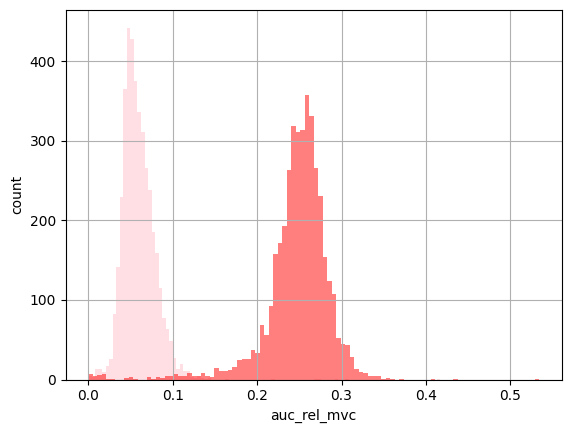

In [ ]:
# @title Were participants squeezing for the correct force and duration? Yes
lo_grip = trial_data_renamed_cts.query('gf_trPer==0.05')
hi_grip = trial_data_renamed_cts.query('gf_trPer==0.4')
lo_grip['auc_rel_mvc'].hist(bins=100, alpha=0.5, color='pink')
hi_grip['auc_rel_mvc'].hist(bins=100, alpha=0.5, color='red')
plt.xlabel("auc_rel_mvc")
plt.ylabel("count")
plt.show()

- as a reminder, auc_rel_mvc is calculated by:
  ```
  auc_rel_mvc = auc / mvc
  ```
  where auc is the area under the curve of the participant's gripforce trajectory for that trial Note that for BAP, this recording is from the start of the handgrip indicator to the start of the response 1 screen ("yes/no")

In [ ]:
trial_data_renamed_cts.groupby(['isStrength']).count()['trial']

isStrength
0    4140
1    4140
Name: trial, dtype: int64

In [ ]:
trial_data_renamed_cts

,index,sub,mvc,ses,task,run,filepath,trial,stimLev,stimLev_i,...,cr_4,auc,auc_prop_targ,auc_rel_mvc,prop_valid_grip_samples,conf_median,resp2_bin_temp,resp2_bin_0,resp2_bin_1,resp2_bin_med
0,0,11,16426,1,cdt,1,/content/G/Shareddrives/LC-Aging/Young Adult -...,1.0,5,1,...,0,857.302292,1.043836,0.052192,1.000000,4.0,0,70,0,0
1,1,11,16426,1,cdt,1,/content/G/Shareddrives/LC-Aging/Young Adult -...,2.0,45,3,...,0,405.444126,0.493661,0.024683,0.672840,4.0,0,70,0,0
2,2,11,16426,1,cdt,1,/content/G/Shareddrives/LC-Aging/Young Adult -...,3.0,20,2,...,0,123.567335,0.018807,0.007523,0.000000,4.0,0,70,0,0
3,3,11,16426,1,cdt,1,/content/G/Shareddrives/LC-Aging/Young Adult -...,4.0,20,2,...,0,3454.146132,0.525713,0.210285,0.969136,4.0,2,70,0,1
4,4,11,16426,1,cdt,1,/content/G/Shareddrives/LC-Aging/Young Adult -...,5.0,20,2,...,0,1071.189112,1.30426,0.065213,1.000000,4.0,2,70,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8275,175,88,21577,4,cdt,3,/content/G/Shareddrives/LC-Aging/Young Adult -...,176.0,5,1,...,0,5742.604585,0.665362,0.266145,1.000000,4.0,2,31,0,1
8276,176,88,21577,4,cdt,3,/content/G/Shareddrives/LC-Aging/Young Adult -...,177.0,45,3,...,0,1691.636103,1.567999,0.0784,1.000000,4.0,2,31,0,1
8277,177,88,21577,4,cdt,3,/content/G/Shareddrives/LC-Aging/Young Adult -...,178.0,45,3,...,0,6015.664756,0.697,0.2788,1.000000,4.0,2,31,0,1
8278,178,88,21577,4,cdt,3,/content/G/Shareddrives/LC-Aging/Young Adult -...,179.0,90,4,...,0,1506.573066,1.396462,0.069823,1.000000,4.0,2,31,0,1


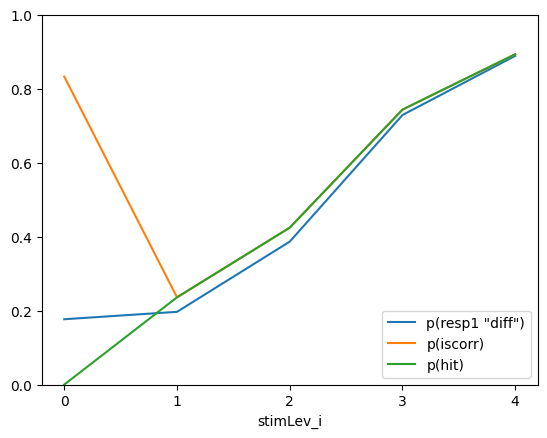

In [ ]:
# @title Is performance generally increasing with stimlev? Yes

trial_data_renamed_cts.groupby('stimLev_i').mean(numeric_only=True)['resp1_diff'].plot(label='p(resp1 "diff")')
trial_data_renamed_cts.groupby('stimLev_i').mean(numeric_only=True)['iscorr'].plot(label='p(iscorr)')
trial_data_renamed_cts.groupby('stimLev_i').mean(numeric_only=True)['hit'].plot(label='p(hit)')
# trial_data_renamed_cts.groupby('stimLev_i').mean(numeric_only=True)['fa'].plot(label='p(fa)')
# trial_data_renamed_cts.groupby('stimLev_i').mean(numeric_only=True)['cr'].plot(label='p(cr)')
# trial_data_renamed_cts.groupby('stimLev_i').mean(numeric_only=True)['miss'].plot(label='p(miss)')
plt.legend()
plt.ylim([0, 1])
# plt.ylabel("proportion resp1='different'")
plt.xticks([0, 1, 2, 3, 4])
plt.show()

# Save trial-level data


In [ ]:
data_dir = '/content/G/Shareddrives/LC-Aging/Young Adult - Behavioral + Pupillometry Study/Data Collection/metacog YA'
save_csv = input('Save CSV? (y/n): ')
if save_csv=='y':
  trial_data_renamed_cts.to_csv(os.path.join(data_dir, 'lcya_behdata_trial_cdt.csv'), index=None)

Save CSV? (y/n): y


In [ ]:
data_dir = '/content/G/Shareddrives/LC-Aging/Young Adult - Behavioral + Pupillometry Study/Data Collection/metacog YA'
trial_data = pd.read_csv(os.path.join(data_dir, 'lcya_behdata_trial_cdt.csv'))

In [ ]:
trial_data.groupby(['resp1_diff', 'stimLev']).agg({'resp1RT':'mean', 'trial': 'count'})

resp1RT  trial
resp1_diff stimLev                 
0.0        0        1.434274   1285
           5        1.468993   1265
           20       1.510397    953
           45       1.537739    424
           90       1.410297    176
1.0        0        1.642604    276
           5        1.628529    310
           20       1.641290    601
           45       1.551510   1142
           90       1.470468   1415